<a href="https://www.kaggle.com/code/lalit7881/e-commerce-customer-behavior?scriptVersionId=302520309" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kojibrand/name-online-shopping-customer-behavior/online_shopping_customer_behavior (1).csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/kojibrand/name-online-shopping-customer-behavior/online_shopping_customer_behavior (1).csv')

In [3]:
df.head()

,customer_id,gender,age,country,device_type,product_category,time_spent_minutes,items_viewed,items_purchased,total_spent_usd
0,CUST_1,Male,40,Australia,Tablet,Clothing,87,12,8,1187
1,CUST_2,Female,38,Pakistan,Tablet,Electronics,71,22,3,153
2,CUST_3,Male,36,UK,Tablet,Clothing,59,20,8,1055
3,CUST_4,Male,36,Pakistan,Mobile,Clothing,39,18,3,991
4,CUST_5,Male,53,Canada,Desktop,Electronics,3,1,1,588


In [4]:
df.tail()

,customer_id,gender,age,country,device_type,product_category,time_spent_minutes,items_viewed,items_purchased,total_spent_usd
1795,CUST_1796,Female,62,USA,Mobile,Clothing,61,30,2,425
1796,CUST_1797,Male,20,USA,Desktop,Clothing,87,12,3,1344
1797,CUST_1798,Female,44,India,Mobile,Electronics,21,35,0,1194
1798,CUST_1799,Male,60,Pakistan,Mobile,Clothing,88,11,3,1231
1799,CUST_1800,Male,57,Canada,Mobile,Clothing,68,44,0,472


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         1800 non-null   object
 1   gender              1800 non-null   object
 2   age                 1800 non-null   int64 
 3   country             1800 non-null   object
 4   device_type         1800 non-null   object
 5   product_category    1800 non-null   object
 6   time_spent_minutes  1800 non-null   int64 
 7   items_viewed        1800 non-null   int64 
 8   items_purchased     1800 non-null   int64 
 9   total_spent_usd     1800 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 140.8+ KB


In [6]:
df.describe()

,age,time_spent_minutes,items_viewed,items_purchased,total_spent_usd
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,41.144444,60.544444,24.542778,4.606667,778.503333
std,13.481514,34.717237,14.041840,2.852841,434.788777
min,18.000000,1.000000,1.000000,0.000000,5.000000
25%,30.000000,30.000000,13.000000,2.000000,400.750000
50%,41.000000,60.000000,24.000000,5.000000,802.000000
75%,53.000000,91.000000,36.000000,7.000000,1146.250000
max,64.000000,119.000000,49.000000,9.000000,1499.000000


In [7]:
df.dtypes

customer_id           object
gender                object
age                    int64
country               object
device_type           object
product_category      object
time_spent_minutes     int64
items_viewed           int64
items_purchased        int64
total_spent_usd        int64
dtype: object

In [8]:
df.shape

(1800, 10)

In [9]:
df.isnull().sum()

customer_id           0
gender                0
age                   0
country               0
device_type           0
product_category      0
time_spent_minutes    0
items_viewed          0
items_purchased       0
total_spent_usd       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['customer_id', 'gender', 'age', 'country', 'device_type',
       'product_category', 'time_spent_minutes', 'items_viewed',
       'items_purchased', 'total_spent_usd'],
      dtype='object')

In [12]:
df.nunique()

customer_id           1800
gender                   2
age                     47
country                  6
device_type              3
product_category         6
time_spent_minutes     119
items_viewed            49
items_purchased         10
total_spent_usd       1052
dtype: int64

## EDA

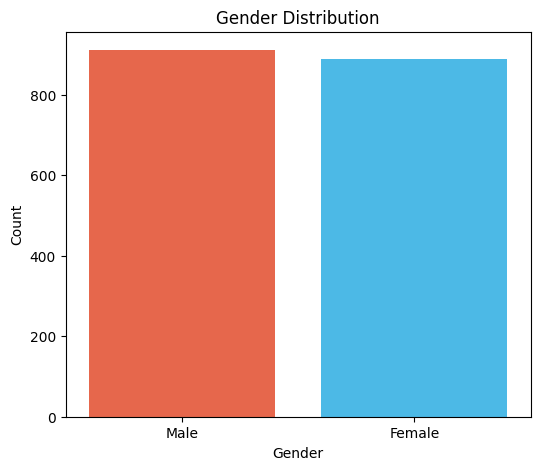

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(x='gender', data=df, palette=['#FF5733','#33C3FF'])

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

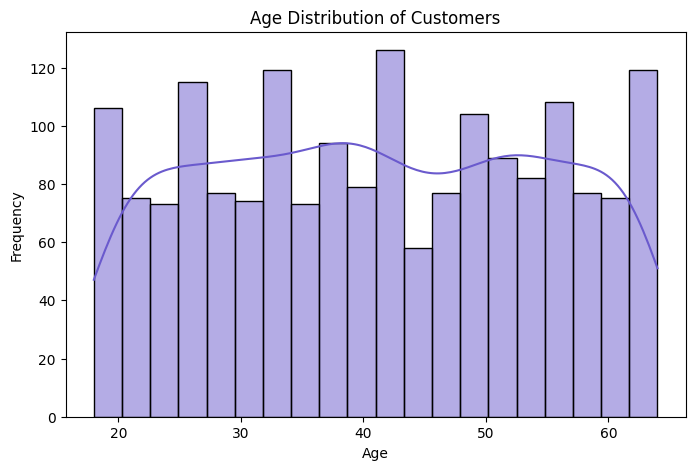

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, color='#6A5ACD', kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

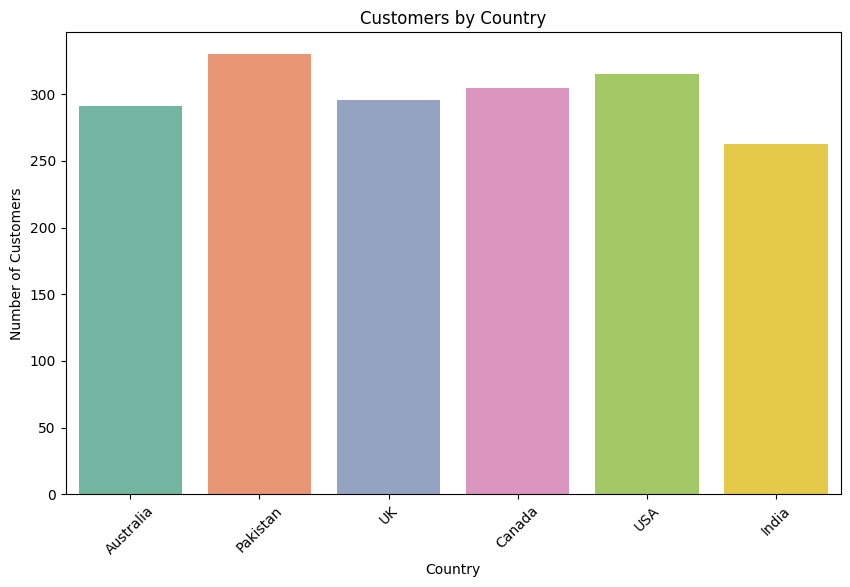

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(x='country', data=df, palette='Set2')

plt.title("Customers by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

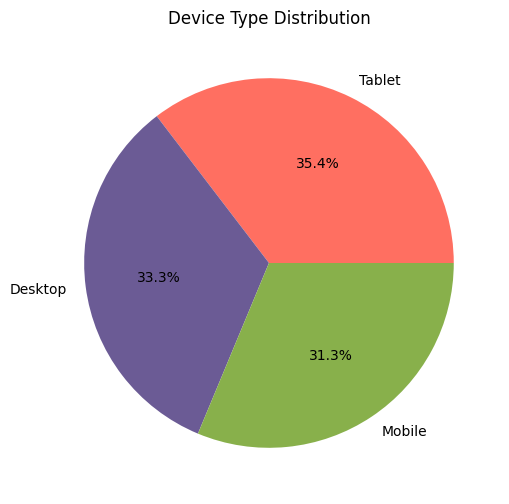

In [16]:
plt.figure(figsize=(6,6))

df['device_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#FF6F61','#6B5B95','#88B04B']
)

plt.title("Device Type Distribution")
plt.ylabel("")

plt.show()

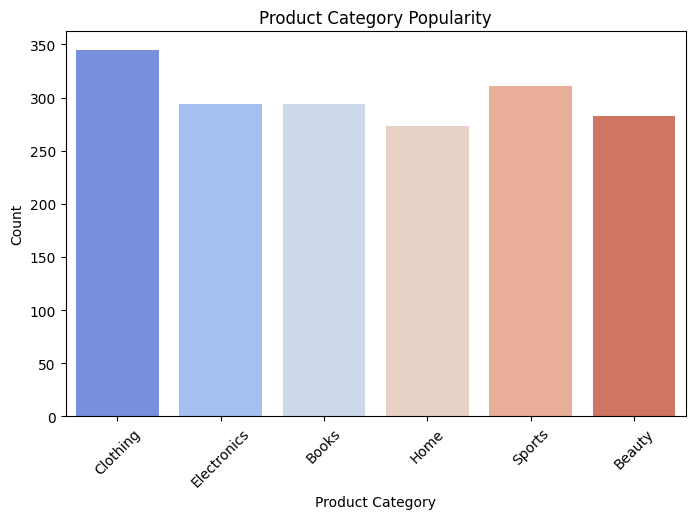

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='product_category',
    data=df,
    palette='coolwarm'
)

plt.title("Product Category Popularity")
plt.xlabel("Product Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

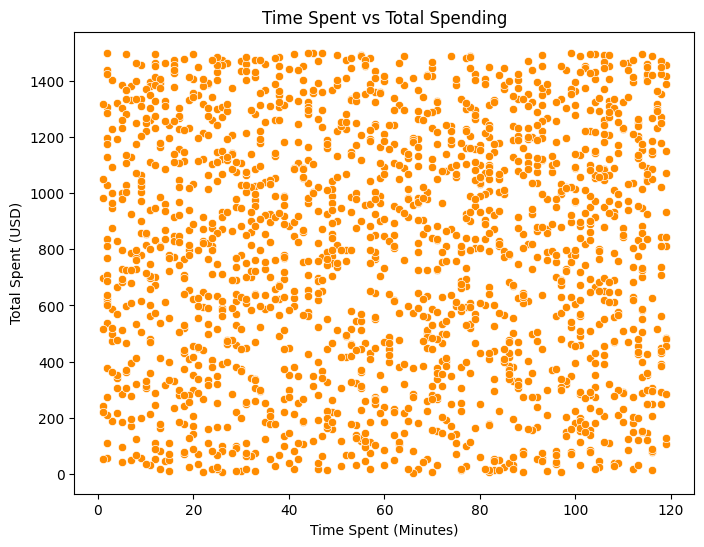

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='time_spent_minutes',
    y='total_spent_usd',
    data=df,
    color='#FF8C00'
)

plt.title("Time Spent vs Total Spending")
plt.xlabel("Time Spent (Minutes)")
plt.ylabel("Total Spent (USD)")

plt.show()

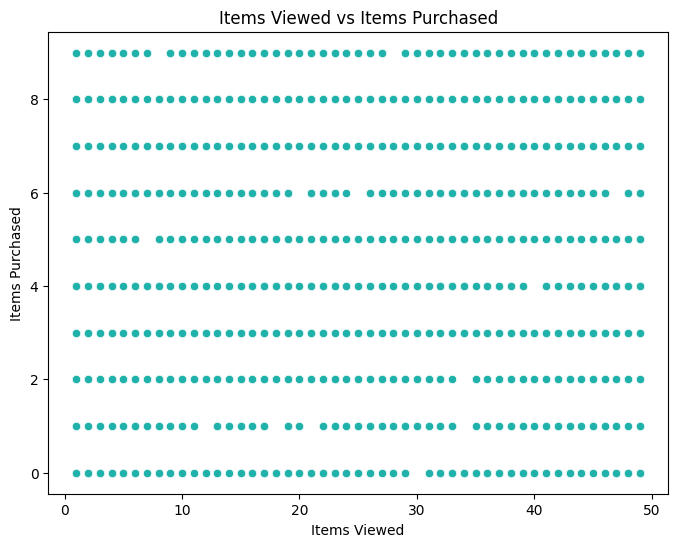

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='items_viewed',
    y='items_purchased',
    data=df,
    color='#20B2AA'
)

plt.title("Items Viewed vs Items Purchased")
plt.xlabel("Items Viewed")
plt.ylabel("Items Purchased")

plt.show()

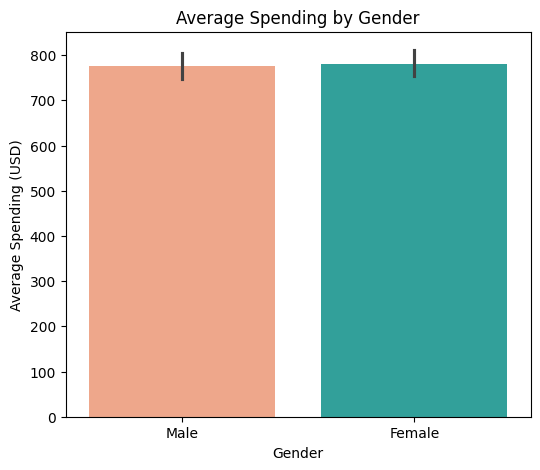

In [20]:
plt.figure(figsize=(6,5))

sns.barplot(
    x='gender',
    y='total_spent_usd',
    data=df,
    palette=['#FFA07A','#20B2AA']
)

plt.title("Average Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Spending (USD)")

plt.show()

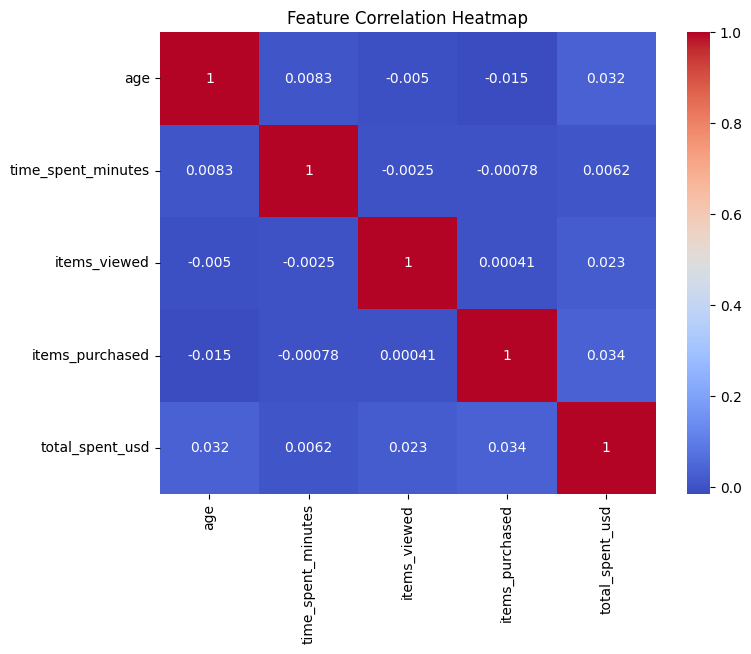

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [23]:
df_model = df.copy()

In [24]:
le = LabelEncoder()

for col in ['customer_id','gender','country','device_type','product_category']:
    df_model[col] = le.fit_transform(df_model[col])

In [25]:
df_model['high_purchase'] = (df_model['items_purchased'] > 3).astype(int)

In [26]:
X = df_model.drop(['items_purchased','high_purchase'], axis=1)
y = df_model['high_purchase']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "Support Vector Machine": SVC(probability=True),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()
}

In [30]:
results = {}

for name, model in models.items():

    print("\n"+"="*60)
    print("MODEL:", name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    print("Accuracy:", round(acc*100,2),"%")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))


MODEL: Logistic Regression
Accuracy: 65.56 %

Classification Report

              precision    recall  f1-score   support

           0       0.33      0.01      0.02       123
           1       0.66      0.99      0.79       237

    accuracy                           0.66       360
   macro avg       0.50      0.50      0.40       360
weighted avg       0.55      0.66      0.53       360


MODEL: Decision Tree
Accuracy: 50.56 %

Classification Report

              precision    recall  f1-score   support

           0       0.32      0.38      0.35       123
           1       0.64      0.57      0.60       237

    accuracy                           0.51       360
   macro avg       0.48      0.48      0.47       360
weighted avg       0.53      0.51      0.51       360


MODEL: Random Forest
Accuracy: 56.11 %

Classification Report

              precision    recall  f1-score   support

           0       0.27      0.17      0.21       123
           1       0.64      0.76      

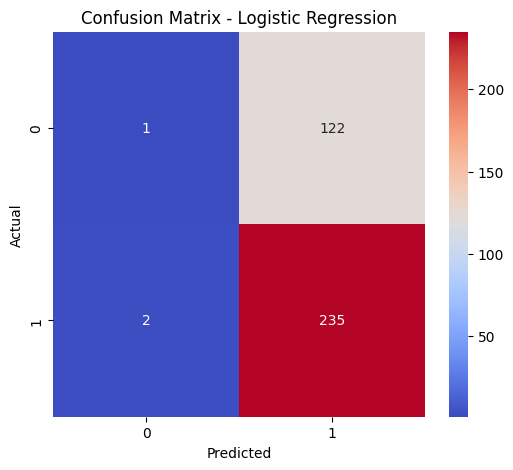

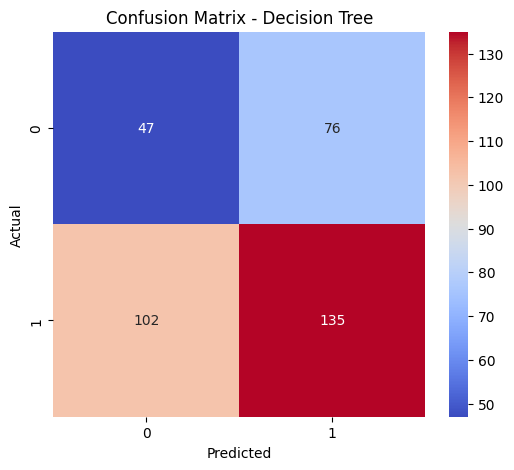

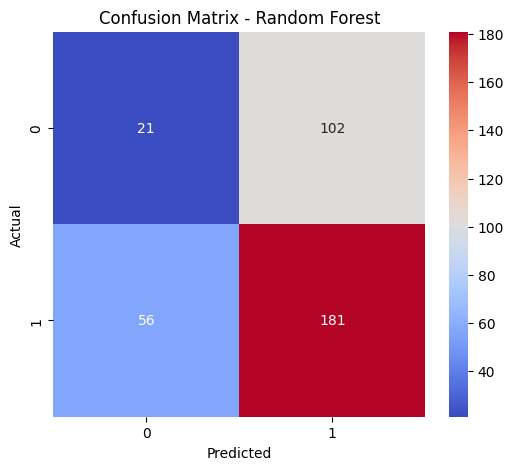

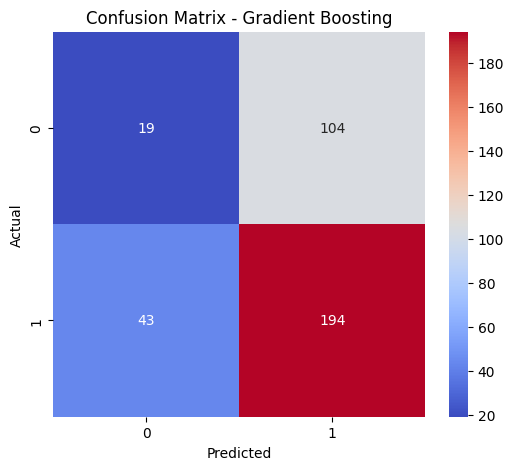

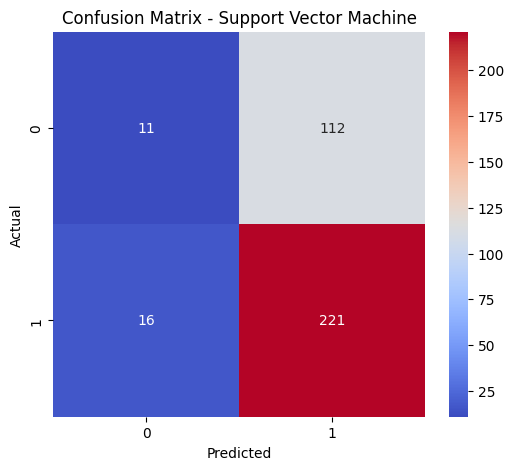

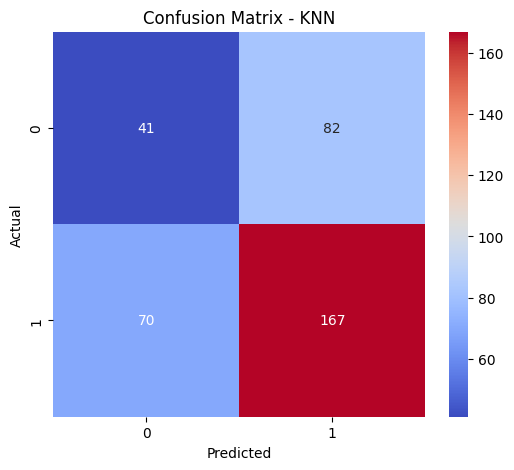

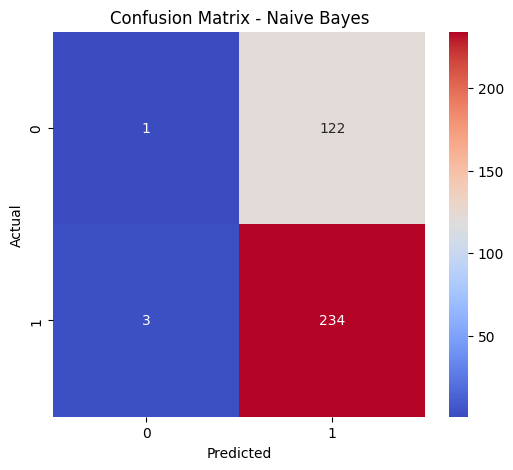

In [31]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')

    plt.title(f"Confusion Matrix - {name}")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

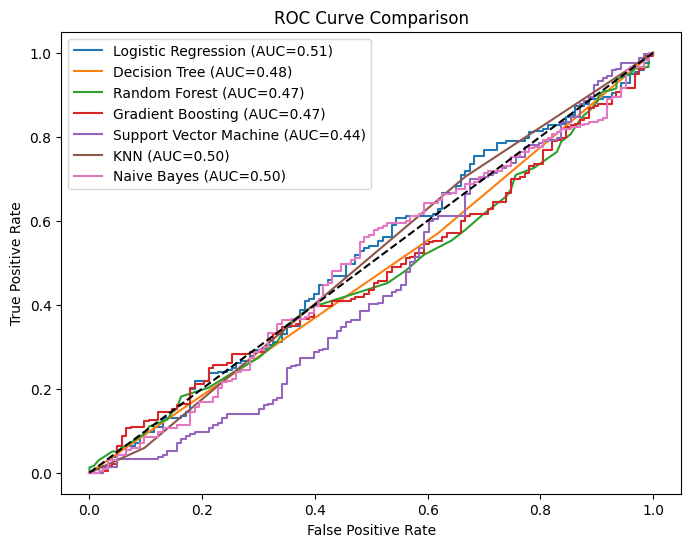

In [32]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

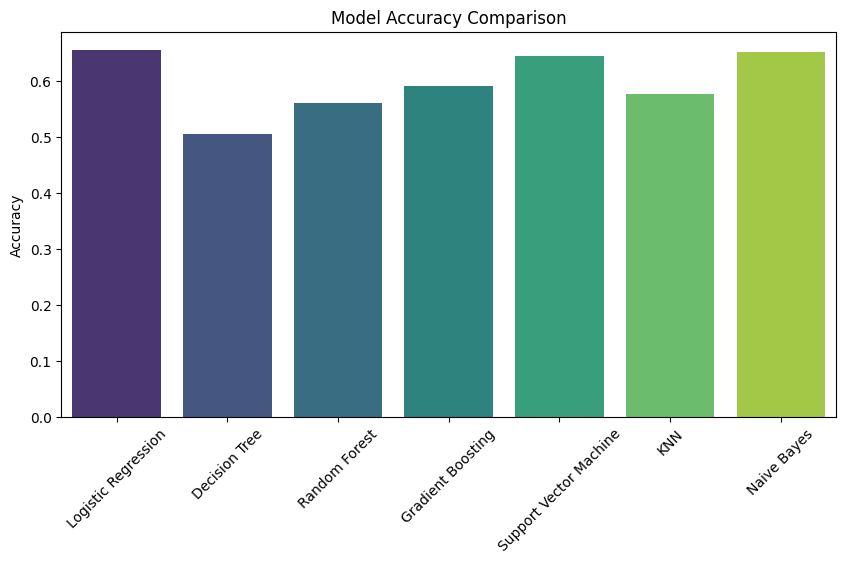

In [33]:
plt.figure(figsize=(10,5))

names = list(results.keys())
values = list(results.values())

sns.barplot(x=names, y=values, palette="viridis")

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.show()

## Thank you...pls upvote!!!!!!